In [15]:
import pandas as pd 
import datetime
import matplotlib.pyplot as plt
import numpy as np
THRESHOLD_TIMESTAMPS = 15

In [ ]:
df = pd.read_csv("events.csv")
print(df.head())

       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN


In [17]:
events_per_user = df["visitorid"].value_counts()

print(events_per_user.head(10))   
print("Median:", events_per_user.median())
print("Mean:", events_per_user.mean())

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
371606     2345
286616     2252
684514     2246
892013     2024
861299     1991
Name: count, dtype: int64
Median: 1.0
Mean: 1.9580421716705267


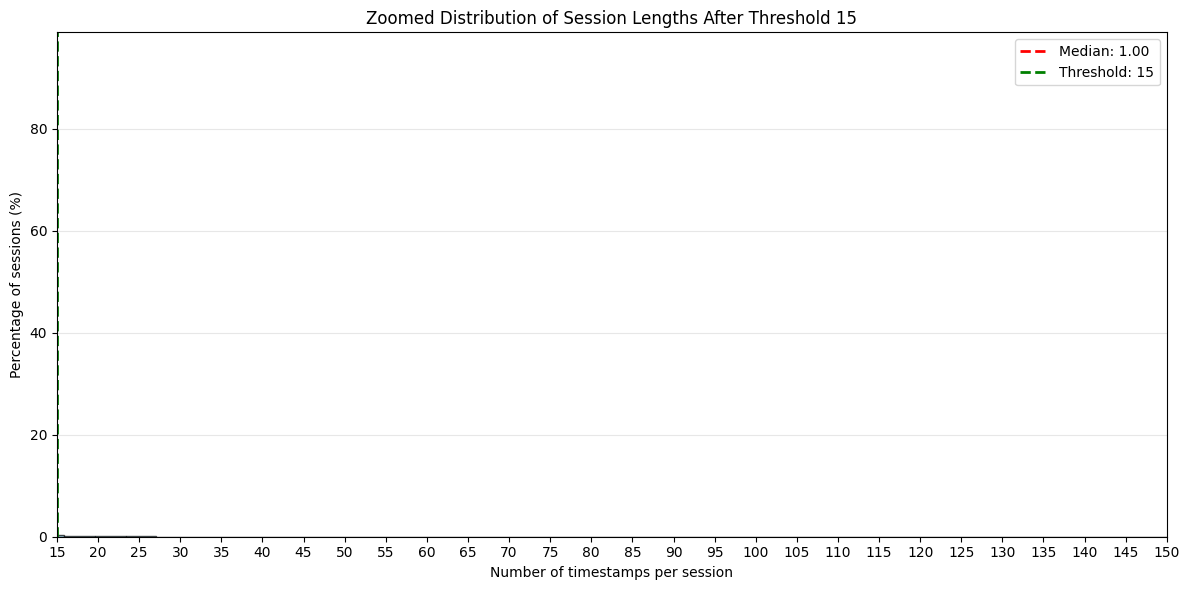

In [18]:
"""
Histograms 
"""


max_range = 150
filtered_for_plot = events_per_user[events_per_user <= max_range]

plt.figure(figsize=(12, 6))

counts, bins = np.histogram(filtered_for_plot, bins=40)
bin_width = bins[1] - bins[0]
counts_percentage = (counts / counts.sum()) * 100

plt.bar(
    bins[:-1],
    counts_percentage,
    width=bin_width,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    align="edge"
)


plt.axvline(
    events_per_user.median(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median: {np.median(events_per_user):.2f}"
)

plt.axvline(
    THRESHOLD_TIMESTAMPS,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Threshold: {THRESHOLD_TIMESTAMPS}"
)

plt.xlim(THRESHOLD_TIMESTAMPS, max_range)

plt.xticks(list(range(THRESHOLD_TIMESTAMPS, max_range+1, 5)))

plt.title(f"Zoomed Distribution of Session Lengths After Threshold {THRESHOLD_TIMESTAMPS}")
plt.xlabel("Number of timestamps per session")
plt.ylabel("Percentage of sessions (%)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
events_per_user = df["visitorid"].value_counts()

print(events_per_user.head(2000000))   # los más activos
print("Max events per user:", events_per_user.max())
print("User with most events:", events_per_user.idxmax())
print("Median:", events_per_user.median())
print("Mean:", events_per_user.mean())

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
           ... 
698825        1
843029        1
1271425       1
394545        1
1184451       1
Name: count, Length: 1407580, dtype: int64
Max events per user: 7757
User with most events: 1150086
Median: 1.0
Mean: 1.9580421716705267


In [20]:
users_with_one_event = (events_per_user == 1).sum()
total_users = len(events_per_user)
percentage_one_event = (users_with_one_event / total_users) * 100
print("User Activity")
print(f"Total of users: {total_users:,}")
print(f"Users with only one event: {users_with_one_event:,}")
print(f" % of people with one percent: {percentage_one_event:.2f}%")

User Activity
Total of users: 1,407,580
Users with only one event: 1,001,560
 % of people with one percent: 71.15%


In [21]:
users_with_few_events = (events_per_user.isin([1, 2, 3, 4, 5])).sum()
total_users = len(events_per_user)
percentage_few_events = (users_with_few_events / total_users) * 100

print("User Activity")
print(f"Total users: {total_users:,}")
print(f"Users with 1–5 events: {users_with_few_events:,}")
print(f"Percentage of users with 1–5 events: {percentage_few_events:.2f}%")


User Activity
Total users: 1,407,580
Users with 1–5 events: 1,348,927
Percentage of users with 1–5 events: 95.83%


In [22]:
print(f"Total of the dataset lenght {len(df)}")

total_users_events = df["visitorid"].value_counts()
print(events_per_user.median())

users_passed_time_stemps = (total_users_events >= THRESHOLD_TIMESTAMPS)
users_passed = total_users_events[users_passed_time_stemps]
print(f"Total of the dataset after the Threshold {len(users_passed)}")
print(f"Median of timestamps per user after the Threshold {users_passed.mean()}")



Total of the dataset lenght 2756101
1.0
Total of the dataset after the Threshold 11201
Median of timestamps per user after the Threshold 39.6508347468976


In [33]:
total_sessions = len(total_users_events)
kept_sessions = len(users_passed)
lost_sessions = total_sessions - kept_sessions

percent_lost = (lost_sessions / total_sessions) * 100
print(f"{percent_lost:.2f}%")

98.35%
